**Amber Locasto Project**

# Breast Cancer Classification Using Machine Learning

## Project Goal
The goal of this project is to build a machine learning model that can classify breast tumors as malignant or benign based on cell nuclei measurements. This project demonstrates a complete machine learning workflow, including data loading, exploration, preprocessing, model training, evaluation, and visualization.

## Why This Project Matters
Breast cancer detection is an important medical problem. Machine learning can help identify patterns in diagnostic measurements and support classification tasks in healthcare and pathology-related settings.


In [ ]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer #using the built in breast cancer dataset
from sklearn.model_selection import train_test_split #splits data into training and test data
from sklearn.preprocessing import StandardScaler #standardizes the data so they are on similar scales
from sklearn.linear_model import LogisticRegression #first classification model
from sklearn.ensemble import RandomForestClassifier #second classification model
from sklearn.metrics import (
    accuracy_score, #how often the model is correct
    classification_report, #precision, recall and f1 score
    confusion_matrix, #shows exact prediction breakdowns
    ConfusionMatrixDisplay #visual display of the CM
)

sns.set_theme(style="whitegrid")
print("✅Libraries imported successfully!✅")

✅Libraries imported successfully!✅


In [ ]:
#loading dataset
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names) #creating a dataframe for the predictor varibales (x will contain the input features like mean radius, meantexture...)
y = pd.Series(data.target, name="target") #target variable, this is the answer column the model is trying to predict

df = X.copy()
df["target"] = y #adds the numeric target columns to the dataframe
df["diagnosis"] = df["target"].map({0: "malignant", 1: "benign"})

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


**EXPLORING THE DATA**

In [ ]:
df.shape #checking number of rows and columns

(569, 32)

In [ ]:
df.info() #column names, number of non-null values, data types and memory used

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
df.isnull().sum().sort_values(ascending=False).head(10) #checking for missing values

mean radius               0
mean texture              0
mean perimeter            0
mean area                 0
mean smoothness           0
mean compactness          0
mean concavity            0
mean concave points       0
mean symmetry             0
mean fractal dimension    0
dtype: int64

In [ ]:
df.describe().T.head(10) #count, mean, std, min, 25%, 50%, 75% and max values for each column

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


In [ ]:
df["diagnosis"].value_counts() #counting how many begnign and malignant samples we have

diagnosis
benign       357
malignant    212
Name: count, dtype: int64

Text(0.5, 1.0, 'Distribution of Diagnosis')

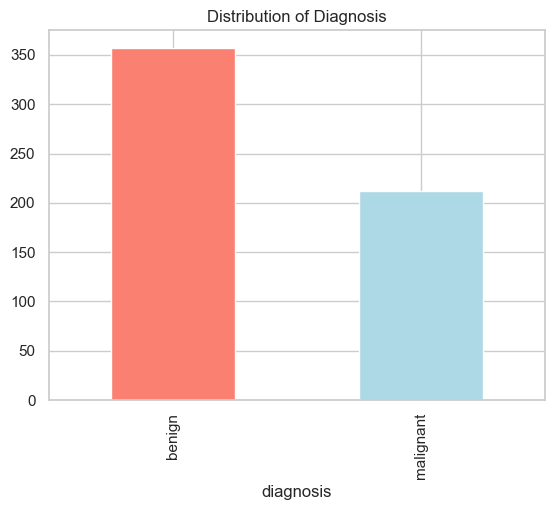

In [10]:
df["diagnosis"].value_counts().plot(kind="bar", color=["salmon", "lightblue"])
plt.title("Distribution of Diagnosis")

## INITIAL FINDINGS
- The data set contains diagnostic measurements from breast cell nuclei
- There are no major missing value issues
- The target variable has two classes: malignant and benign.
- The dataset is structured and suitable for classificaiton modeling. 

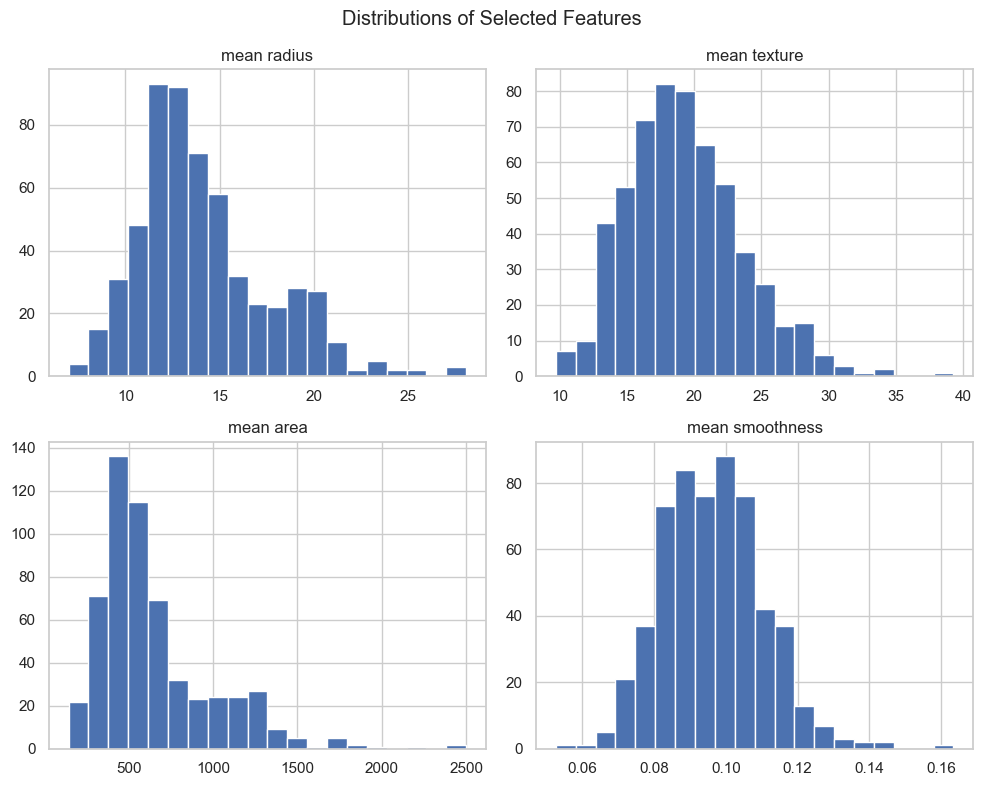

In [11]:
features_to_plot = ["mean radius", "mean texture", "mean area", "mean smoothness"]

df[features_to_plot].hist(figsize=(10,8), bins=20)
plt.suptitle("Distributions of Selected Features")
plt.tight_layout()
plt.show()

**histogram tells us where most values fall, wether the distributions are symmetric or skewed, wether there are outliers or not, and wether the features vary a lot**

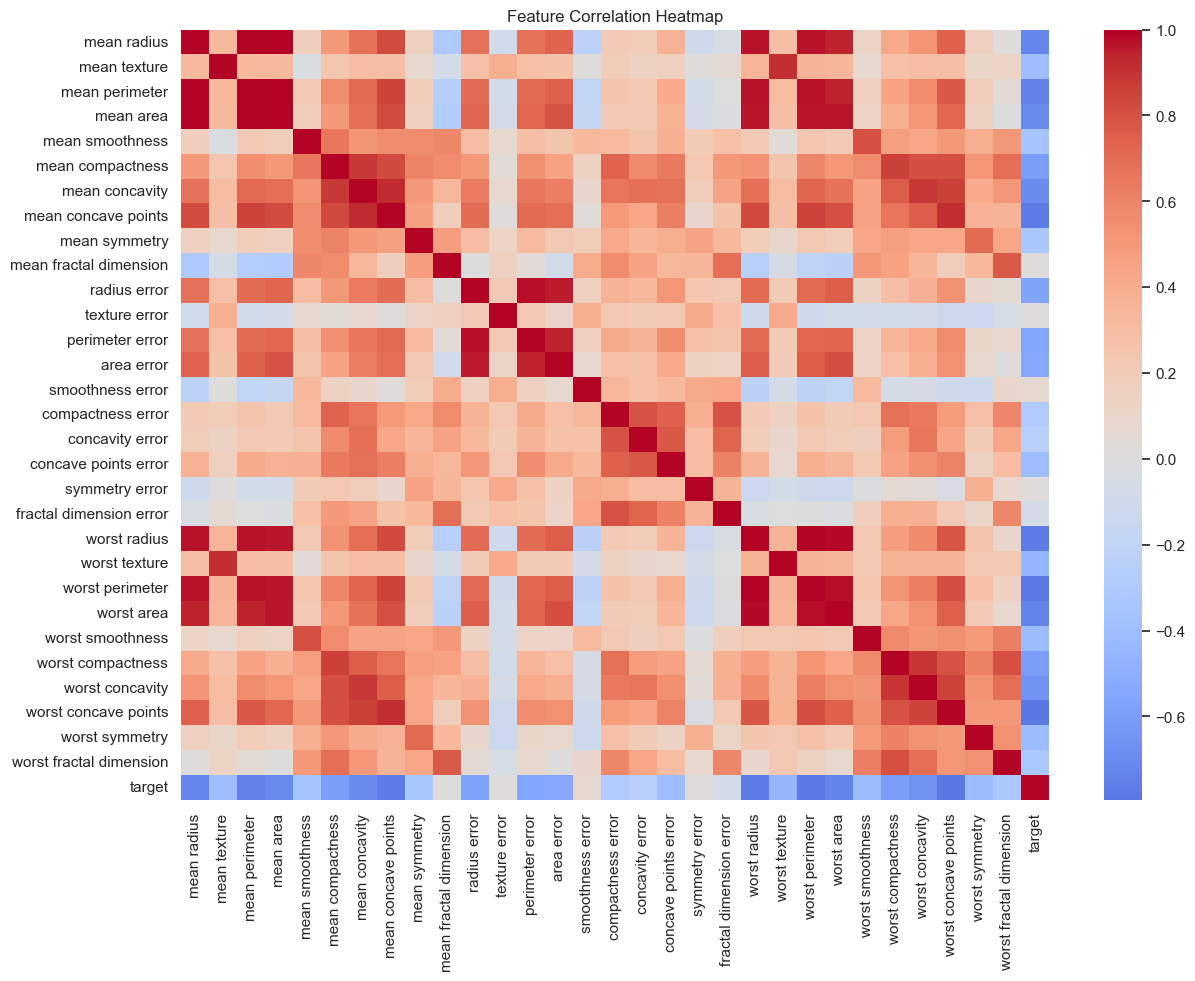

In [12]:
plt.figure(figsize=(14,10))
corr = df.drop(columns=["diagnosis"]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

close to 1 --> strong + relationship

close to -1 --> strong - relationship

close to 0 --> weak/no linear relationship

**PREPARING THE DATA FOR MODELING**

In [ ]:
#splitting the data
X = df.drop(columns=["target", "diagnosis"]) #creating the feature matrix -- drop the columns with the answers we want to predict so the model wont see it
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y #20% test set, 80% training set
) #stratify = y preserves the same class proportions in the train and test sets

In [ ]:
#scaling 
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) 
#mean around 0, std around 1, all features on similar scales

**scaling matters because mean area may have much larger values and mean smootheness may have much smaller values that will not correspond with each other well in the model**

In [ ]:
#first model - logistic regression
log_model = LogisticRegression(max_iter=10000)
log_model.fit(X_train_scaled, y_train) #model is learning

y_pred_log = log_model.predict(X_test_scaled) #model making predictions on data it has not seen before

log_accuracy = accuracy_score(y_test, y_pred_log) #compares predicted labels to the true labels and calculates the percent correct
print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.9824561403508771


In [ ]:
print(classification_report(y_test, y_pred_log, target_names=data.target_names)) #precision, recall and f1 score for each class

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



- precision = of all cases predicted as a class, how many were correct?

- recall = of all cases in a class, how many did the model correctly find?

- f1 score = balance between precision and recall

- support = how many true examples of that class were in the test set?

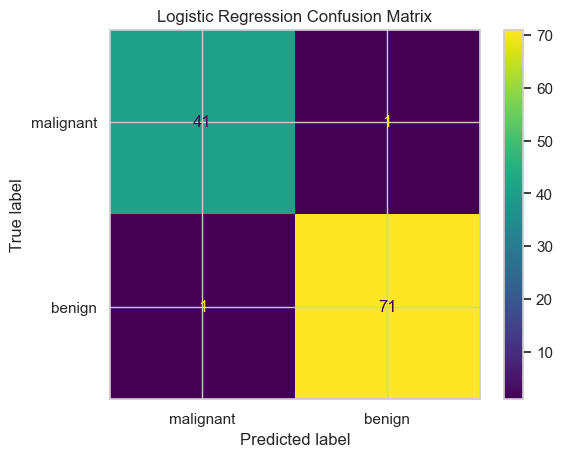

In [ ]:
cm = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show() #to show us WHERE the mistakes happened, how many there were and which class was the hardest to classify

- how many malignant were correctly predicted

- how many benign were correctly predicted?

- how many were misclassified?

In [ ]:
#second model - random forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train) #tree-based models do not require scaling

y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.956140350877193


In [21]:
print(classification_report(y_test, y_pred_rf, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



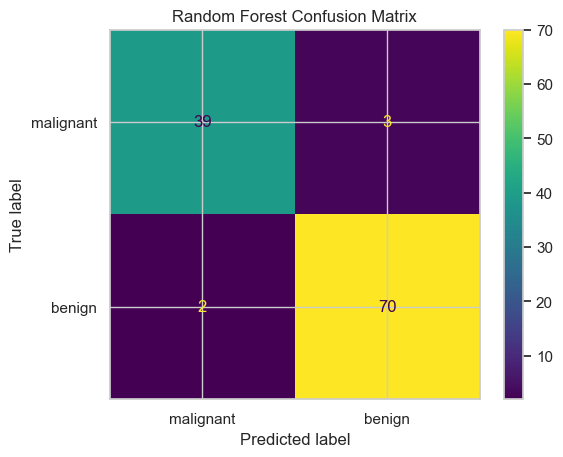

In [22]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=data.target_names)
disp_rf.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

**COMPARING MODELS**

In [23]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [log_accuracy, rf_accuracy]
})

results

,Model,Accuracy
0,Logistic Regression,0.982456
1,Random Forest,0.956140


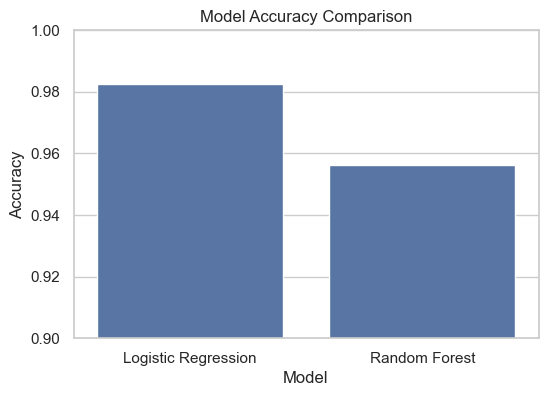

In [24]:
plt.figure(figsize=(6,4))
sns.barplot(data=results, x="Model", y="Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0.9, 1.0)
plt.show()

**FEATURE IMPORTANCE FOR RANDOM FOREST**

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)
#measuring how useful each feature was for the random forest model, higher importance means the feature was more useful for making accurate predictions

,Feature,Importance
23,worst area,0.140016
27,worst concave points,0.129530
20,worst radius,0.097696
7,mean concave points,0.090885
22,worst perimeter,0.072226
2,mean perimeter,0.069574
0,mean radius,0.068676
6,mean concavity,0.057638
3,mean area,0.049172
26,worst concavity,0.034340


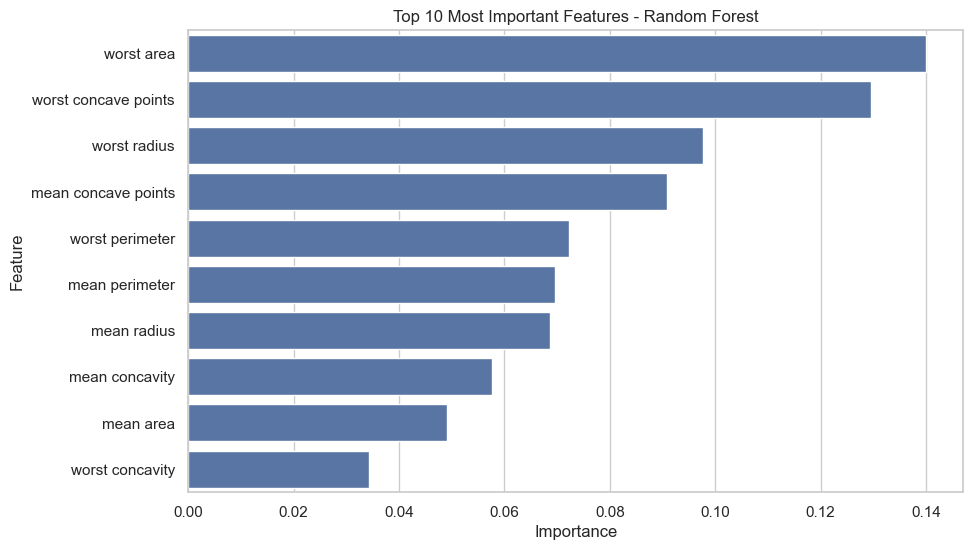

In [26]:
plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance.head(10), x="Importance", y="Feature")
plt.title("Top 10 Most Important Features - Random Forest")
plt.show()

# Conclusion

This project demonstrated a complete machine learning workflow using a medical dataset related to breast cancer diagnosis. Two classification models were trained: Logistic Regression and Random Forest.

## Key Results
- Both models performed well on the test set.
- The Random Forest model provided useful feature importance rankings.
- Measurements such as radius, perimeter, area, and texture were among the more important predictors.

## What I Learned
- How to load and explore biomedical data in Python
- How to preprocess data for machine learning
- How to split data into training and testing sets
- How to train and evaluate classification models
- How to interpret results using confusion matrices and feature importance

## Future Improvements
- Tune hyperparameters
- Try additional models such as SVM or XGBoost
- Use cross-validation
- Explore more medical or histology-specific datasets

In [31]:
# Export files for Power BI
df.to_csv("breast_cancer_classification.csv", index=False)
results.to_csv("model_results.csv", index=False)
feature_importance.to_csv("feature_importance.csv", index=False)

print("Files exported successfully.")

Files exported successfully.
